In [1]:
# Some useful settings for interactive work
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
# Importing the necessary libraries
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

import figs.render.capture_generation as pg
import figs.visualize.plot_trajectories as pt
import figs.visualize.generate_videos as gv

from figs.simulator import Simulator
from figs.control.vehicle_rate_mpc import VehicleRateMPC

from figs.dynamics.model_equations import export_glider_ode_model
from figs.dynamics.model_specifications import generate_glider_specifications

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


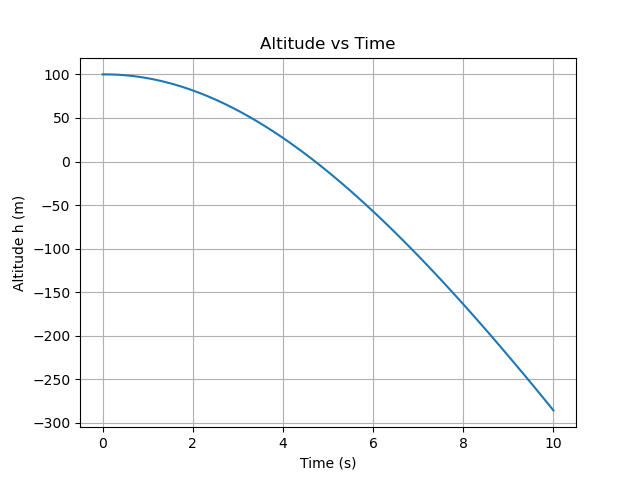

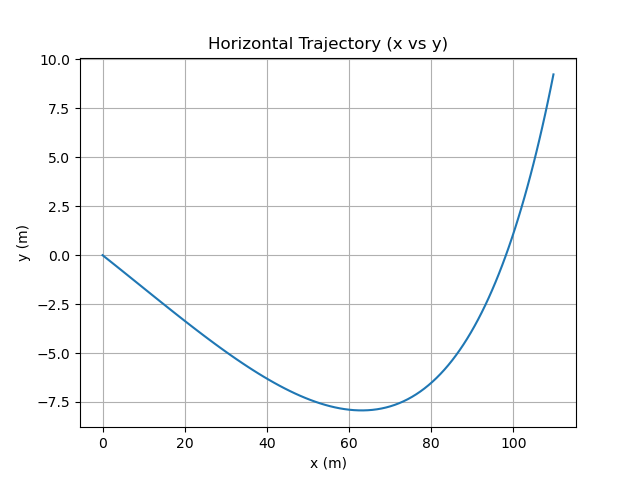

In [ ]:
drn_prms = {
    # PHX airframe (no payload)
    'mass': 1.9,            # kg  (4.2 lb)
    'wing_area': 0.28,      # m²  (≈1.4 m span, AR≈7 → S=1.4²/7)
    'air_density': 1.225,   # kg/m³ (sea level std)
    'gravity': 9.81,        # m/s²

    # Lift polar:  C_L = a1·α + a0
    #   a1 ≈ 2π·AR/(2 + √(4+AR²)) ≈ 4.8–5.2 per rad
    'a1': 5.0,
    'a0': 0.0,

    # Drag polar:  C_D = k·α² + C_D0
    #   C_D0 ≈ 0.02,  k ≈ 1/(π·AR·e) ≈ 0.05
    'b2': 0.05,
    'b0': 0.02,

    # Control limits
    'alpha_min': -0.5,      # rad
    'alpha_max': +0.5,      # rad
    'phi_min':   -np.pi/4,  # rad
    'phi_max':   +np.pi/4,  # rad
    'beta_min':  0.0,       # sideslip usually small
    'beta_max':  0.0
}

# 2) Build the model
specs = generate_glider_specifications(drn_prms)
model = export_glider_ode_model(specs)
f = ca.Function('f', [model.x, model.u], [model.f_expl_expr])

# 3) Simulation settings
dt = 0.1       # time step [s]
T_total = 10.0 # total sim time [s]
n_steps = int(T_total / dt)

# 4) Initial state: [x, y, h, V, gamma, psi, tau]
x0 = np.array([0.0, 0.0, 100.0, 15.0, 0.0, 0.0, 0.0])

# 5) Constant control: slight roll bank φ = 0.1 rad (~5.7°), zero angle of attack and sideslip
u_const = np.array([0.0, 0.1, 0.0])

# 6) Allocate storage
states = np.zeros((n_steps+1, 7))
times = np.linspace(0, T_total, n_steps+1)
states[0] = x0

# 7) Forward Euler integration
for k in range(n_steps):
    xk = states[k]
    xdot_dm = f(xk, u_const)
    xdot = np.array(xdot_dm).flatten()
    states[k+1] = xk + dt * xdot

# 8) Plot trajectory in the horizontal plane (x vs y)
plt.figure()
plt.plot(states[:,0], states[:,1])
plt.title('Horizontal Trajectory (x vs y)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(True)

# 9) Plot altitude over time
plt.figure()
plt.plot(times, states[:,2])
plt.title('Altitude vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Altitude h (m)')
plt.grid(True)

plt.show()

In [4]:
# # FiGS Capture Examples (scene_name, capture_name)
# capture_examples = [
#     'backroom'
# ]

# # FiGS Simulate Examples (scene_name, rollout_name, frame_name, policy_name, course_name)
# simulate_examples = [
#     ('flightroom', 'baseline', 'carl', 'vrmpc_fr', 'extended_traj_track'),
#     ('backroom',   'baseline', 'carl', 'vrmpc_fr', 'cluttered_env_track'),
#     ('mid_gate',   'baseline', 'carl', 'vrmpc_fr', 'robustness_track'),
#     ('src_open',   'baseline', 'carl', 'vrmpc_fr', 'infinity')
# ]

In [5]:
# # Generate the FiGS environment
# for scene_name in capture_examples:
#     print("=============================================================")
#     print(f"Generating GSplat for [{scene_name}]")
#     print("-------------------------------------------------------------")

#     pg.generate_gsplat(scene_name)

In [6]:
# # Simulate within the FiGS environment
# for scene, rollout, frame, policy, course in simulate_examples:
#     print("=============================================================")
#     print(f"Simulating {scene} scene with {course} course")
#     print("-------------------------------------------------------------")

#     # Load the policy and simulator
#     sim = Simulator(scene,rollout,frame)
#     ctl = VehicleRateMPC(course,policy,frame)

#     # Use the ideal trajectory in VehicleRateMPC to get initial conditions and final time
#     t0,tf,x0 = ctl.tXUd[0,0],ctl.tXUd[0,-1],ctl.tXUd[1:11,0]

#     # Simulate the policy
#     Tro,Xro,Uro,Imgs,_,_ = sim.simulate(ctl,t0,tf,x0)

#     # Output the results
#     gv.images_to_mp4(Imgs,course+'_'+scene+'.mp4', ctl.hz)       # Save the video
#     pt.plot_RO_spatial((Tro,Xro,Uro))                               # Plot the spatial trajectory

#     # Clear the memory of the policy to avoid improper re-initialization of ACADOS
#     del ctl